### 2024 to 2025 data

In [5]:
# Import pandas for data manipulation
import pandas as pd
# Import numpy for numerical operations
import numpy as np
# Import matplotlib for plotting
import matplotlib.pyplot as plt
# Import matplotlib date formatting utilities
import matplotlib.dates as mdates

# Define the file path to the data file
dir = r'C:\Users\mo alibag\Desktop\IIG_Sushobhan_Mishra\AIML\24_25.txt'
# Read CSV file, skip first 7 rows, no header row, treat whitespace as separator
df = pd.read_csv(dir,skiprows=7,header= None,sep=r'\s+')
# Display the loaded dataframe
print(df)


          0    1   2   3
0      2024    1   0   0
1      2024    1   1   2
2      2024    1   2   4
3      2024    1   3   5
4      2024    1   4   3
...     ...  ...  ..  ..
17539  2025  365  19  14
17540  2025  365  20  14
17541  2025  365  21  12
17542  2025  365  22  10
17543  2025  365  23  13

[17544 rows x 4 columns]


In [16]:
# Define the file path to the data file
dir1 = r'C:\Users\mo alibag\Desktop\IIG_Sushobhan_Mishra\AIML\26_jan.txt'
# Read CSV file, skip first 7 rows, no header row, treat whitespace as separator
df1 = pd.read_csv(dir1,skiprows=7,header= None,sep=r'\s+')
# Display the loaded dataframe
print(df1)

       0  1   2   3
0   2026  1   0   3
1   2026  1   1   4
2   2026  1   2   2
3   2026  1   3   4
4   2026  1   4  13
5   2026  1   5  19
6   2026  1   6  20
7   2026  1   7  18
8   2026  1   8   5
9   2026  1   9   1
10  2026  1  10   4
11  2026  1  11   8
12  2026  1  12   4
13  2026  1  13   3
14  2026  1  14  -1
15  2026  1  15  -4
16  2026  1  16  -8
17  2026  1  17 -12
18  2026  1  18  -8
19  2026  1  19  -6
20  2026  1  20  -8
21  2026  1  21 -10
22  2026  1  22 -17
23  2026  1  23  -8


In [17]:
# Assign column names to the dataframe
df1.columns =['YEAR','DOY','HOUR','DST']
# Display the dataframe with named columns
print(df1)

    YEAR  DOY  HOUR  DST
0   2026    1     0    3
1   2026    1     1    4
2   2026    1     2    2
3   2026    1     3    4
4   2026    1     4   13
5   2026    1     5   19
6   2026    1     6   20
7   2026    1     7   18
8   2026    1     8    5
9   2026    1     9    1
10  2026    1    10    4
11  2026    1    11    8
12  2026    1    12    4
13  2026    1    13    3
14  2026    1    14   -1
15  2026    1    15   -4
16  2026    1    16   -8
17  2026    1    17  -12
18  2026    1    18   -8
19  2026    1    19   -6
20  2026    1    20   -8
21  2026    1    21  -10
22  2026    1    22  -17
23  2026    1    23   -8


In [6]:
# Assign column names to the dataframe
df.columns =['YEAR','DOY','HOUR','DST']
# Display the dataframe with named columns
print(df)


       YEAR  DOY  HOUR  DST
0      2024    1     0    0
1      2024    1     1    2
2      2024    1     2    4
3      2024    1     3    5
4      2024    1     4    3
...     ...  ...   ...  ...
17539  2025  365    19   14
17540  2025  365    20   14
17541  2025  365    21   12
17542  2025  365    22   10
17543  2025  365    23   13

[17544 rows x 4 columns]


In [10]:
# Import MinMaxScaler for data normalization
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler object for normalization to 0-1 range
scaler_minmax = MinMaxScaler()
# Apply Min-Max scaling to DST column and store result in new column
df['DST_normalized_minmax'] = scaler_minmax.fit_transform(df[['DST']])

# Print header for data statistics
print("Data Statistics:")
# Display mean, std, min, and max of original DST data
print(f"DST - Mean: {df['DST'].mean():.2f}, Std: {df['DST'].std():.2f}, Min: {df['DST'].min()}, Max: {df['DST'].max()}")
# Display min and max of normalized DST data
print(f"DST (MinMax Normalized) - Min: {df['DST_normalized_minmax'].min():.6f}, Max: {df['DST_normalized_minmax'].max():.6f}")
# Print label for normalized data preview
print("\nFirst 5 rows with normalized data:")
# Display first 5 rows of the dataframe
print(df.head())


Data Statistics:
DST - Mean: -12.58, Std: 27.22, Min: -406, Max: 71
DST (MinMax Normalized) - Min: 0.000000, Max: 1.000000

First 5 rows with normalized data:
   YEAR  DOY  HOUR  DST  DST_normalized_minmax
0  2024    1     0    0               0.851153
1  2024    1     1    2               0.855346
2  2024    1     2    4               0.859539
3  2024    1     3    5               0.861635
4  2024    1     4    3               0.857442


In [11]:
# Set input sequence length to 72 hours (3 days)
n_input = 72
# Set output sequence length to 24 hours (1 day)
n_output = 24
# Convert normalized DST series to numpy array
series = df['DST_normalized_minmax'].to_numpy()

# Initialize empty lists for input and output sequences
X, y = [], []
# Loop through the series to create sliding window sequences
for i in range(len(series) - n_input - n_output + 1):
    # Append 72-hour input window to X
    X.append(series[i : i + n_input])
    # Append 24-hour output window to y
    y.append(series[i + n_input : i + n_input + n_output])

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

# Print number of sequences generated
print(f"\nGenerated {len(X)} sequences.")
# Print shape of input and output arrays
print(f"Input shape: {X.shape}, Output shape: {y.shape}")
# Print shape of single input sample
print("Sample input window shape:", X[0].shape)
# Print shape of single output sample
print("Sample output window shape:", y[0].shape)



Generated 17449 sequences.
Input shape: (17449, 72), Output shape: (17449, 24)
Sample input window shape: (72,)
Sample output window shape: (24,)


In [ ]:
# Import Sequential model and supporting layers for neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reshape X to 3D array for LSTM: [samples, timesteps, features]
X_lstm = X.reshape((X.shape[0], X.shape[1], 1))

# Calculate split index for 80-20 train-validation split
split_index = int(len(X_lstm) * 0.8)
# Split X into training and validation sets
X_train, X_val = X_lstm[:split_index], X_lstm[split_index:]
# Split y into training and validation sets
y_train, y_val = y[:split_index], y[split_index:]

# Build a deeper LSTM model with dropout for better generalization
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(n_input, 1)),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(n_output)
])

# Compile model with a lower learning rate and MSE loss
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Define callbacks for early stopping and learning rate reduction
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Train the model with a smaller batch size and no shuffle for time-series data
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    shuffle=False,
    verbose=2
)

# Get last 72-hour window from the dataset
last_input = X_lstm[-1].reshape(1, n_input, 1)
# Make prediction for next 24 hours (normalized values)
y_pred_norm = model.predict(last_input)

# Inverse transform predictions to original DST scale
y_pred_24h = scaler_minmax.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()

# Print header for predictions
print("\nPredicted next 24 hours of DST:")
# Display predicted DST values
print(y_pred_24h)

# Check if validation data exists
if len(y_val) > 0:
    # Inverse transform last true 24-hour window to original scale
    y_true_24h = scaler_minmax.inverse_transform(y[-1].reshape(-1, 1)).flatten()
    # Print header for true values
    print("\nLast available true next 24-hour window:")
    # Display true DST values
    print(y_true_24h)


c:\Users\mo alibag\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
491/491 - 11s - 22ms/step - loss: 0.0354 - mae: 0.0801 - val_loss: 0.0028 - val_mae: 0.0329
Epoch 2/100
491/491 - 8s - 17ms/step - loss: 0.0024 - mae: 0.0301 - val_loss: 0.0022 - val_mae: 0.0257
Epoch 3/100
491/491 - 8s - 17ms/step - loss: 0.0022 - mae: 0.0279 - val_loss: 0.0035 - val_mae: 0.0488
Epoch 4/100
491/491 - 8s - 17ms/step - loss: 0.0021 - mae: 0.0271 - val_loss: 0.0021 - val_mae: 0.0269
Epoch 5/100
491/491 - 8s - 17ms/step - loss: 0.0021 - mae: 0.0269 - val_loss: 0.0023 - val_mae: 0.0331
Epoch 6/100
491/491 - 8s - 17ms/step - loss: 0.0020 - mae: 0.0258 - val_loss: 0.0020 - val_mae: 0.0259
Epoch 7/100
491/491 - 8s - 17ms/step - loss: 0.0020 - mae: 0.0259 - val_loss: 0.0020 - val_mae: 0.0245
Epoch 8/100
491/491 - 8s - 17ms/step - loss: 0.0019 - mae: 0.0251 - val_loss: 0.0019 - val_mae: 0.0237
Epoch 9/100
491/491 - 8s - 17ms/step - loss: 0.0019 - mae: 0.0256 - val_loss: 0.0020 - val_mae: 0.0249
Epoch 10/100
491/491 - 8s - 17ms/step - loss: 0.0019 - mae: 0.0252 - val

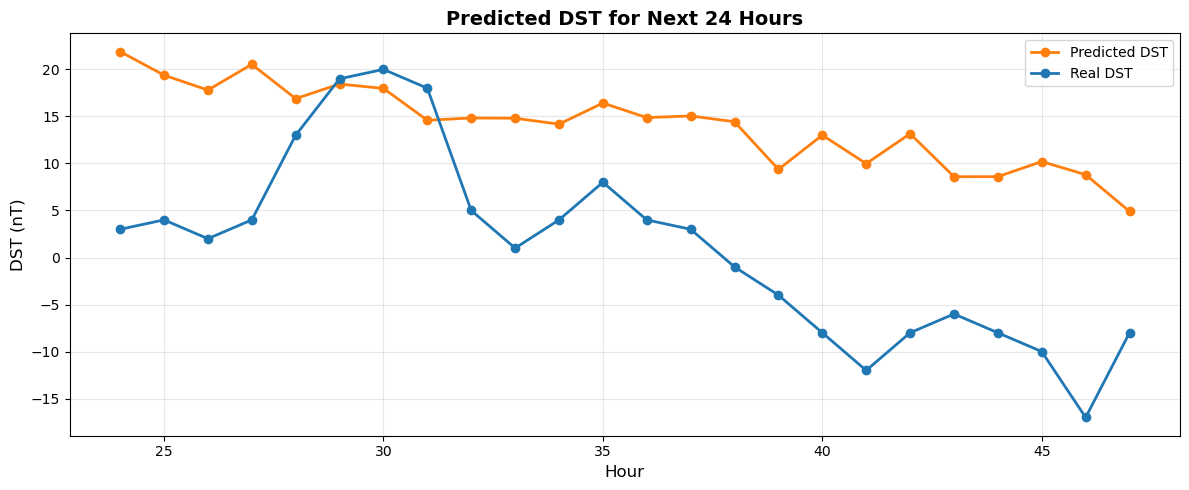

In [20]:
# Get the last hour from the dataframe
last_hour = int(df['HOUR'].iloc[-1])
# Create array of future hours for x-axis (24 hours ahead)
future_hours = np.arange(last_hour + 1, last_hour + 1 + len(y_pred_24h))

# Create a figure with specified size (width=12, height=5)
plt.figure(figsize=(12, 5))
# Plot predicted DST values with markers
plt.plot(future_hours, y_pred_24h, marker='o', linewidth=2, markersize=6, color='tab:orange', label='Predicted DST')
plt.plot(future_hours, df1['DST'], marker='o', linewidth=2, markersize=6, color='tab:blue', label='Real DST')
# Set plot title
plt.title('Predicted DST for Next 24 Hours', fontsize=14, fontweight='bold')
# Set x-axis label
plt.xlabel('Hour', fontsize=12)
# Set y-axis label
plt.ylabel('DST (nT)', fontsize=12)
# Add grid for better readability
plt.grid(True, alpha=0.3)
# Add legend
plt.legend()
# Adjust layout to prevent label cutoff
plt.tight_layout()
# Display the plot
plt.show()



=== Model Performance on Validation Set ===
Root Mean Square Error (RMSE): 20.7270 nT
R² Score: 0.4175


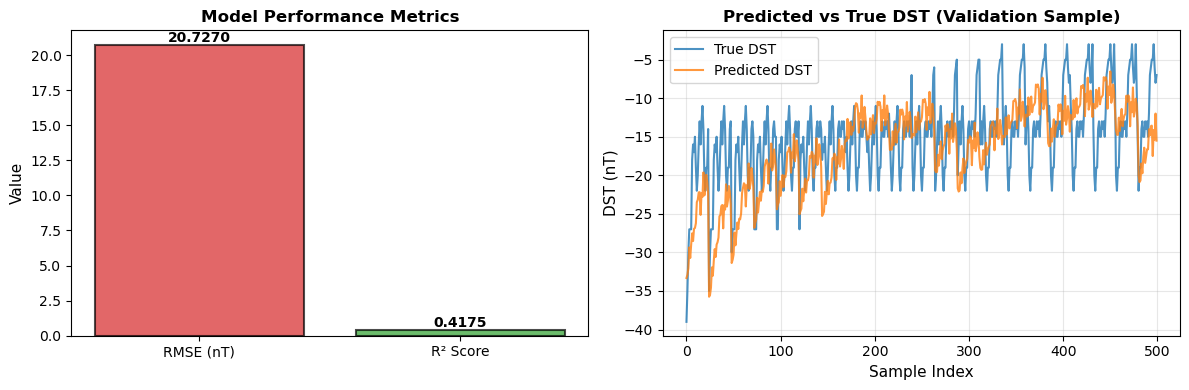

In [15]:
# Import metrics for model evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Generate predictions on validation set without verbose output
y_val_pred_norm = model.predict(X_val, verbose=0)

# Inverse transform validation true values to original DST scale
y_val_true_dst = scaler_minmax.inverse_transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
# Inverse transform validation predicted values to original DST scale
y_val_pred_dst = scaler_minmax.inverse_transform(y_val_pred_norm.reshape(-1, 1)).reshape(y_val_pred_norm.shape)

# Calculate RMSE (square root of mean squared error)
rmse = np.sqrt(mean_squared_error(y_val_true_dst.flatten(), y_val_pred_dst.flatten()))
# Calculate R² score (coefficient of determination)
r2 = r2_score(y_val_true_dst.flatten(), y_val_pred_dst.flatten())

# Print performance metrics header
print(f"\n=== Model Performance on Validation Set ===")
# Print RMSE value in nanoTeslas
print(f"Root Mean Square Error (RMSE): {rmse:.4f} nT")
# Print R² value (0-1 scale, higher is better)
print(f"R² Score: {r2:.4f}")
# Print Mean Absolute Error metric
print(f"Mean Absolute Error (MAE): {np.mean(np.abs(y_val_true_dst - y_val_pred_dst)):.4f} nT")

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Define metrics names for bar chart
metrics = ['RMSE (nT)', 'R² Score']
# Define metric values
values = [rmse, r2]
# Define colors for bars
colors = ['tab:red', 'tab:green']
# Create bar chart of metrics
bars = axes[0].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
# Set title for metrics plot
axes[0].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
# Set y-axis label
axes[0].set_ylabel('Value', fontsize=11)
# Loop through bars to add value labels
for bar, val in zip(bars, values):
    # Get bar height
    height = bar.get_height()
    # Add text label on top of bar with value
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Define slice for first 500 prediction samples
sample_idx = slice(0, 500)
# Plot true validation DST values on right subplot
axes[1].plot(y_val_true_dst.flatten()[sample_idx], label='True DST', linewidth=1.5, alpha=0.8)
# Plot predicted validation DST values on right subplot
axes[1].plot(y_val_pred_dst.flatten()[sample_idx], label='Predicted DST', linewidth=1.5, alpha=0.8)
# Set title for comparison plot
axes[1].set_title('Predicted vs True DST (Validation Sample)', fontsize=12, fontweight='bold')
# Set x-axis label
axes[1].set_xlabel('Sample Index', fontsize=11)
# Set y-axis label
axes[1].set_ylabel('DST (nT)', fontsize=11)
# Add legend showing which line is which
axes[1].legend()
# Add grid for better readability
axes[1].grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()
# Display the plot
plt.show()
